In [108]:
from tokenize import Number

import requests

API_KEY = "mge7jublv8ldXpcWwPPmfAdDtelWwHuA"

url = "https://app.ticketmaster.com/discovery/v2/events.json"

params = {
    "apikey": API_KEY,
    "city": "Stockholm",
    "size": 200
}

response = requests.get(url, params=params)
data = response.json()

print(data)

{'_embedded': {'events': [{'name': 'Pitbull – I’m Back! , Platinum Tickets', 'type': 'event', 'id': 'Z698xZq2Z1k0bqvxp', 'test': False, 'url': 'https://www.ticketmaster.se/event/pitbull--im-back--platinum-tickets-tickets/918741896?language=en-us', 'locale': 'en-us', 'images': [{'ratio': '4_3', 'url': 'https://s1.ticketm.net/dam/a/55e/c39c621f-2b4d-4741-b826-ac768995555e_CUSTOM.jpg', 'width': 305, 'height': 225, 'fallback': False}, {'ratio': '3_2', 'url': 'https://s1.ticketm.net/dam/a/55e/c39c621f-2b4d-4741-b826-ac768995555e_TABLET_LANDSCAPE_3_2.jpg', 'width': 1024, 'height': 683, 'fallback': False}, {'ratio': '16_9', 'url': 'https://s1.ticketm.net/dam/a/918/bd324c03-b456-4cb9-87b2-fe8664cb1918_SOURCE', 'width': 2426, 'height': 1365, 'fallback': False}, {'ratio': '3_2', 'url': 'https://s1.ticketm.net/dam/a/55e/c39c621f-2b4d-4741-b826-ac768995555e_ARTIST_PAGE_3_2.jpg', 'width': 305, 'height': 203, 'fallback': False}, {'ratio': '16_9', 'url': 'https://s1.ticketm.net/dam/a/55e/c39c621f-2b4

In [109]:
import pandas as pd

events = data['_embedded']['events']

rows = []
for event in events:
    rows.append({
        'name': event.get('name'),
        'date': event['dates']['start'].get('localDate'),
        'venue': event['_embedded']['venues'][0].get('name'),
        'genre': event['classifications'][0].get('genre', {}).get('name'),
        'segment': event['classifications'][0].get('segment', {}).get('name'),
        'status': event['dates']['status'].get('code'),
    })

df = pd.DataFrame(rows)
df

,name,date,venue,genre,segment,status
0,"Pitbull – I’m Back! , Platinum Tickets",2026-06-23,3Arena,Rock,Music,onsale
1,Foo Fighters: TAKE COVER TOUR 2026,2026-06-12,Strawberry Arena,Rock,Music,onsale
2,"Matt Rife: Stay Golden World Tour, Platinum Ti...",2026-04-20,None,Comedy,Arts & Theatre,onsale
3,Bad Bunny - DeBÍ TiRAR MáS FOToS World Tour,2026-07-10,Strawberry Arena,Latin,Music,onsale
4,Bad Bunny - DeBÍ TiRAR MáS FOToS World Tour | ...,2026-07-10,Strawberry Arena,Latin,Music,onsale
...,...,...,...,...,...,...
156,MAMMA MIA! THE PARTY,2026-11-26,Tyrol,Theatre,Arts & Theatre,onsale
157,MAMMA MIA! THE PARTY,2026-11-27,Tyrol,Theatre,Arts & Theatre,onsale
158,MAMMA MIA! THE PARTY,2026-11-28,Tyrol,Theatre,Arts & Theatre,onsale
159,MAMMA MIA! THE PARTY,2026-11-28,Tyrol,Theatre,Arts & Theatre,onsale


In [110]:
df['genre'].value_counts()

genre
Theatre             93
Rock                20
Other               13
Hip-Hop/Rap          8
Dance/Electronic     7
Latin                3
Comedy               3
Family               3
Dance                3
Folk                 2
Alternative          2
Martial Arts         1
World                1
Food & Drink         1
Metal                1
Name: count, dtype: int64

In [111]:
df['date'].value_counts().nlargest(3)

date
2026-08-10    3
2026-04-18    3
2026-05-03    3
Name: count, dtype: int64

In [112]:
df['venue'].value_counts().nlargest(10)

venue
Tyrol                     93
Strawberry Arena          14
Cirkus                     5
Förbindelsehallen          3
B-K                        3
Stockholm Waterfront       3
3Arena                     2
Fryshuset                  2
Debaser Nova               2
Dansens Hus Studioscen     2
Name: count, dtype: int64

In [113]:
df['date']

0      2026-06-23
1      2026-06-12
2      2026-04-20
3      2026-07-10
4      2026-07-10
          ...    
156    2026-11-26
157    2026-11-27
158    2026-11-28
159    2026-11-28
160    2027-12-22
Name: date, Length: 161, dtype: object

In [114]:
df['date'] = pd.to_datetime((df['date']))
df['month'] = df['date'].dt.month_name()
print(df[['name', 'date', 'month']].head())


                                                name       date  month
0             Pitbull – I’m Back! , Platinum Tickets 2026-06-23   June
1                 Foo Fighters: TAKE COVER TOUR 2026 2026-06-12   June
2  Matt Rife: Stay Golden World Tour, Platinum Ti... 2026-04-20  April
3        Bad Bunny - DeBÍ TiRAR MáS FOToS World Tour 2026-07-10   July
4  Bad Bunny - DeBÍ TiRAR MáS FOToS World Tour | ... 2026-07-10   July


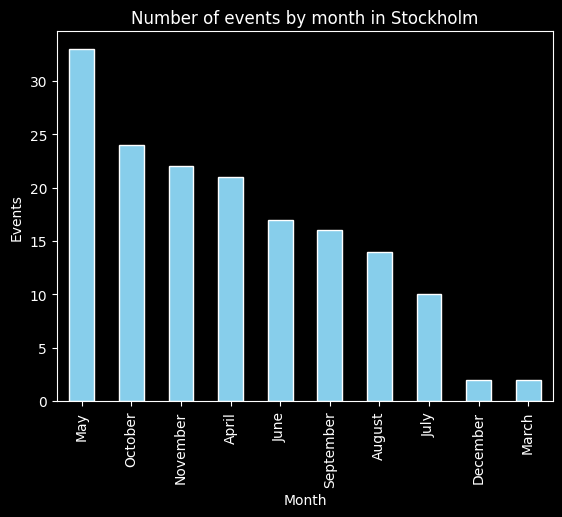

In [132]:
import matplotlib.pyplot as plt

month_counts = df['month'].value_counts()

month_counts.plot(kind='bar', color='skyblue', edgecolor='white')

plt.title('Number of events by month in Stockholm')
plt.xlabel('Month')
plt.ylabel('Events')

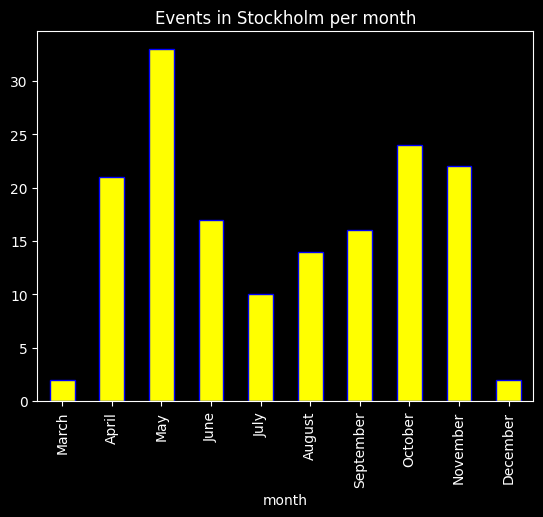

In [131]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

counts = df['month'].value_counts()

counts_sorted = counts.reindex(month_order).dropna()

counts_sorted.plot(kind='bar', color='yellow', edgecolor='blue')
plt.title("Events in Stockholm per month")

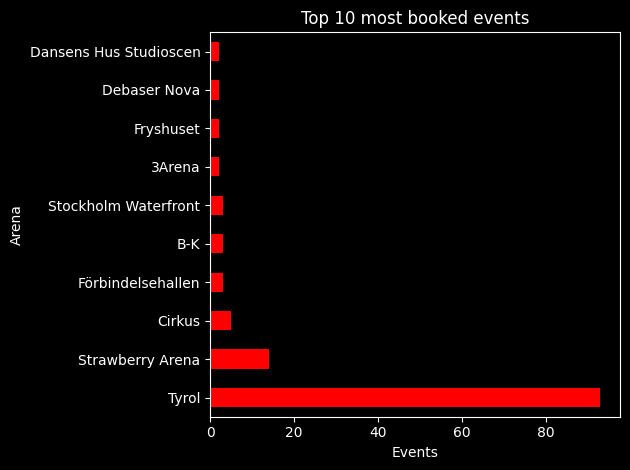

In [130]:
venue_counts = df['venue'].value_counts()

top_10_venues = venue_counts.head(10)

top_10_venues.plot(kind='barh', color='red')

plt.title("Top 10 most booked events")
plt.xlabel("Events")
plt.ylabel('Arena')
plt.tight_layout()

In [172]:
import duckdb

rock_query = """
SELECT name, venue, date, genre
FROM df
WHERE genre LIKE '%Rock%'
"""

rock_events = duckdb.query(rock_query).to_df()
print("Rock conserts in Stockholm:") # Pitbull WTF?
print(rock_events)

Rock conserts in Stockholm:
                                                 name             venue  \
0              Pitbull – I’m Back! , Platinum Tickets            3Arena   
1                  Foo Fighters: TAKE COVER TOUR 2026  Strawberry Arena   
2   Bad Bunny - DeBÍ TiRAR MáS FOToS World Tour | ...  Strawberry Arena   
3   LINKIN PARK - From Zero World Tour 2026, Plati...            3Arena   
4     Joe Bonamassa: Live in concert,Platinum Tickets              None   
5   5 Seconds of Summer - EVERYONE'S A STAR! WORLD...             Hovet   
6                                    System Of A Down  Strawberry Arena   
7                       Deep Purple, Platinum tickets              None   
8                       Tame Impala, Platinum Tickets              None   
9             RUSH, FIFTY SOMETHING, Platinum Tickets              None   
10                                Patti Smith Quartet            Cirkus   
11                                Patti Smith Quartet            Cirkus 

In [173]:
debug_query = "SELECT name, genre FROM df"
print(duckdb.query(debug_query).to_df())

                                                  name    genre
0               Pitbull – I’m Back! , Platinum Tickets     Rock
1                   Foo Fighters: TAKE COVER TOUR 2026     Rock
2    Matt Rife: Stay Golden World Tour, Platinum Ti...   Comedy
3          Bad Bunny - DeBÍ TiRAR MáS FOToS World Tour    Latin
4    Bad Bunny - DeBÍ TiRAR MáS FOToS World Tour | ...    Latin
..                                                 ...      ...
156                               MAMMA MIA! THE PARTY  Theatre
157                               MAMMA MIA! THE PARTY  Theatre
158                               MAMMA MIA! THE PARTY  Theatre
159                               MAMMA MIA! THE PARTY  Theatre
160              Sofia GA 0522 Real - Do not purchases   Family

[161 rows x 2 columns]


In [174]:
%%sql
SELECT name,venue, date, genre
FROM df
WHERE genre = 'Rock'
AND venue IS NOT NULL
AND venue != 'None'
ORDER BY date

,name,venue,date,genre
0,5 Seconds of Summer - EVERYONE'S A STAR! WORLD...,Hovet,2026-04-18,Rock
1,Sofia Isella,Fryshuset,2026-05-16,Rock
2,"LINKIN PARK - From Zero World Tour 2026, Plati...",3Arena,2026-05-29,Rock
3,Foo Fighters: TAKE COVER TOUR 2026,Strawberry Arena,2026-06-12,Rock
4,"Pitbull – I’m Back! , Platinum Tickets",3Arena,2026-06-23,Rock
5,System Of A Down,Strawberry Arena,2026-06-29,Rock
6,Bad Bunny - DeBÍ TiRAR MáS FOToS World Tour | ...,Strawberry Arena,2026-07-11,Rock
7,Patti Smith Quartet,Cirkus,2026-07-22,Rock
8,Patti Smith Quartet,Cirkus,2026-07-23,Rock


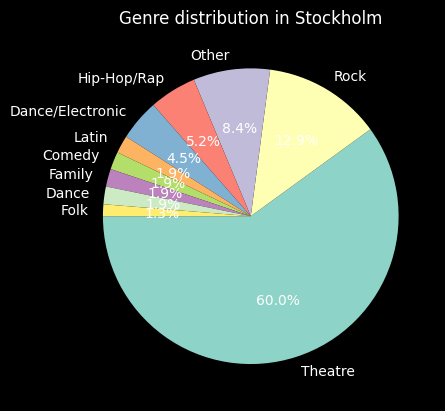

In [175]:
genre_distribution = df['genre'].value_counts().head(10)

genre_distribution.plot(kind='pie', autopct='%1.1f%%', startangle=180)
plt.title('Genre distribution in Stockholm')
plt.ylabel('')

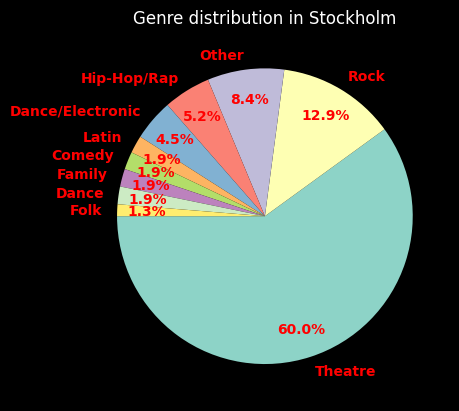

In [176]:
df['genre'].value_counts().head(10).plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=180,
    pctdistance=0.80,
    textprops={'color':"red", 'weight':'bold', 'fontsize':10}
)

plt.title('Genre distribution in Stockholm', color='white')
plt.ylabel('')

In [178]:
import duckdb

music_query = """
SELECT *
FROM df
WHERE segment = 'Music'
"""

df_music = duckdb.query(music_query).to_df()

In [179]:
print(f"Number of rows in full set: {len(df)}")
print(f"Number of rows in music only: {len(df_music)}")

Number of rows in full set: 161
Number of rows in music only: 57


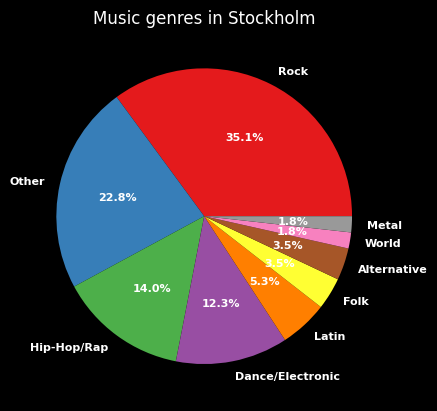

In [193]:
df_music['genre'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colormap='Set1',
    textprops={'color':"white", 'weight':'bold', 'fontsize':8}
)
plt.title("Music genres in Stockholm")
plt.ylabel('')